In [7]:
# Pentest Agent LLM Fine-Tuning Script v2 (Bug Fixed)
# Bu script PicklingError hatasını gidermek için SFTConfig ve Trainer yapılandırmasını günceller.

import torch
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig # SFTConfig eklendi
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

# 1. Model ve Tokenizer Yapılandırması
max_seq_length = 2048
dtype = None
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Llama-3.2-3B-Instruct",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# 2. LoRA Yapılandırması
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

# 3. Veri Seti Hazırlama
dataset_name = "7h3-R3v3n4n7/pentest-agent-dataset-chatml"
dataset = load_dataset(dataset_name, split = "train")

def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
    return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)

# 4. Eğitim Ayarları (PicklingError Çözümü İçin Güncellendi)
# Bazı ortamlarda TrainingArguments ve SFTTrainer arasındaki uyumsuzluk bu hataya yol açar.
# SFTConfig kullanarak daha stabil bir yapı kuruyoruz.

training_args = SFTConfig(
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    warmup_steps = 5,
    max_steps = 1000,
    learning_rate = 2e-4,
    fp16 = not is_bfloat16_supported(),
    bf16 = is_bfloat16_supported(),
    logging_steps = 1,
    optim = "adamw_8bit",
    weight_decay = 0.01,
    lr_scheduler_type = "linear",
    seed = 3407,
    output_dir = "outputs",
    report_to = "none", # Hata olasılığını azaltmak için raporlamayı kapatıyoruz
)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    args = training_args,
)

# 5. Eğitimi Başlat
trainer_stats = trainer.train()

# 6. Modeli Kaydetme
model.save_pretrained("pentest_llm_lora")
tokenizer.save_pretrained("pentest_llm_lora")

print("Eğitim başarıyla tamamlandı!")

==((====))==  Unsloth 2026.6.7: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


Map:   0%|          | 0/322511 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/322511 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 322,511 | Num Epochs = 1 | Total steps = 1,000
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,2.639469
2,3.062402
3,3.099797
4,2.171724
5,2.579631
6,2.472387
7,2.461684
8,2.206968
9,2.215598
10,1.829040


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in pentest_llm_lora/tokenizer_config.json.


Eğitim başarıyla tamamlandı!


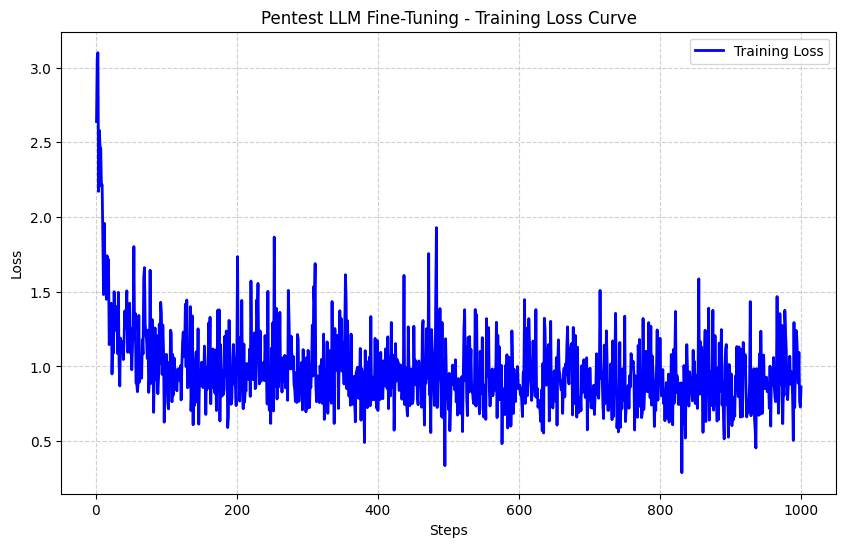

Final Loss: 0.8627


In [9]:
import matplotlib.pyplot as plt

# Eğitim geçmişinden loss değerlerini çekelim
history = trainer.state.log_history
steps = [x['step'] for x in history if 'loss' in x]
loss = [x['loss'] for x in history if 'loss' in x]

# Grafiği çizdirelim
plt.figure(figsize=(10, 6))
plt.plot(steps, loss, label='Training Loss', color='blue', linewidth=2)
plt.title('Pentest LLM Fine-Tuning - Training Loss Curve')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print(f"Final Loss: {loss[-1]:.4f}")


In [10]:
from unsloth import FastLanguageModel

# 1. Modeli çıkarım (inference) moduna alalım
FastLanguageModel.for_inference(model)

# 2. Test sorumuzu hazırlayalım (ChatML formatında)
messages = [
    {"role": "user", "content": "192.168.1.50 hedef IP adresinde kapsamlı bir port taraması yapmak istiyorum. Hangi Nmap komutunu kullanmalıyım ve neden?"},
]

# 3. Tokenize edip modeli çalıştıralım
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True,
    return_tensors = "pt",
).to("cuda")

outputs = model.generate(input_ids = inputs, max_new_tokens = 512, use_cache = True)
response = tokenizer.batch_decode(outputs)

# 4. Sonucu yazdıralım
print(response[0].split("<|im_start|>assistant")[-1].replace("<|im_end|>", "").strip())


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 18 Jun 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

192.168.1.50 hedef IP adresinde kapsamlı bir port taraması yapmak istiyorum. Hangi Nmap komutunu kullanmalıyım ve neden?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Nmap komutu ile port taraması yapabilirsiniz. Nmap komutu ile port taraması yapabilmeniz için hedef IP adresinin port numarasını bilmeniz gerekir. Nmap komutu ile port taraması yapabilmeniz için target IP adresinin port numarasını bilmeniz gerekir. Nmap komutu ile port taraması yapabilmeniz için target IP adresinin port numarasını bilmeniz gerekir. Nmap komutu ile port taraması yapabilmeniz için target IP adresinin port numarasını bilmeniz gerekir. Nmap komutu ile port taraması yapabilmeniz için target IP adresinin port numarasını bilmeniz gerekir. Nmap komutu ile port taraması yapabilmeniz için target IP adresinin port numarasını bilmeniz

In [11]:
import shutil
from google.colab import files

# Klasörü ziple
shutil.make_archive("pentest_model", 'zip', "pentest_llm_lora")

# Bilgisayarına indir
files.download("pentest_model.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>